# 🎵 Spotify Hit Predictor

## Notebook 5 — Inferencia y demostración de uso

**Rol responsable:**  Data Scientist  

---

### Objetivo del notebook

Este notebook demuestra cómo reutilizar el modelo final ya entrenado para estimar la probabilidad de popularidad de canciones nuevas.

El flujo carga los artefactos guardados:

- Modelo `HistGradientBoostingClassifier`.
- Preprocesador numérico.
- Codificador multi-etiqueta de géneros.
- Metadata y umbrales de decisión.

La salida mostrará:

- Probabilidad estimada de popularidad.
- Resultado con estrategia equilibrada (`umbral = 0.55`).
- Resultado con estrategia de descubrimiento (`umbral = 0.35`).
- Recomendación para revisión humana por parte del equipo A&R.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paleta visual Spotify
spotify_green = "#1DB954"
spotify_black = "#191414"
spotify_dark = "#121212"
spotify_gray = "#B3B3B3"
spotify_white = "#FFFFFF"

# Cargar predicciones ya calculadas por el modelo final
dashboard_path = Path("../reports/tables/dashboard_demo_predictions.csv")

dashboard_data = pd.read_csv(dashboard_path)

print("Predicciones cargadas correctamente.")
print("Filas disponibles:", len(dashboard_data))
print("Columnas disponibles:")
print(dashboard_data.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '..\\reports\\tables\\dashboard_demo_predictions.csv'

In [ ]:
# Indicadores principales del Dashboard Demo

total_canciones = len(dashboard_data)

priorizadas_equilibrada = int(
    dashboard_data["prediccion_equilibrada"].sum()
)

priorizadas_descubrimiento = int(
    dashboard_data["prediccion_descubrimiento"].sum()
)

probabilidad_promedio = dashboard_data[
    "probabilidad_popularidad"
].mean()

print("RESUMEN DEL DASHBOARD")
print("-" * 35)
print(f"Total de canciones evaluadas: {total_canciones:,}")
print(f"Priorizadas — estrategia equilibrada: {priorizadas_equilibrada:,}")
print(f"Priorizadas — estrategia descubrimiento: {priorizadas_descubrimiento:,}")
print(f"Probabilidad promedio de popularidad: {probabilidad_promedio:.2%}")

RESUMEN DEL DASHBOARD
-----------------------------------
Total de canciones evaluadas: 13,460
Priorizadas — estrategia equilibrada: 4,303
Priorizadas — estrategia descubrimiento: 6,828
Probabilidad promedio de popularidad: 38.34%


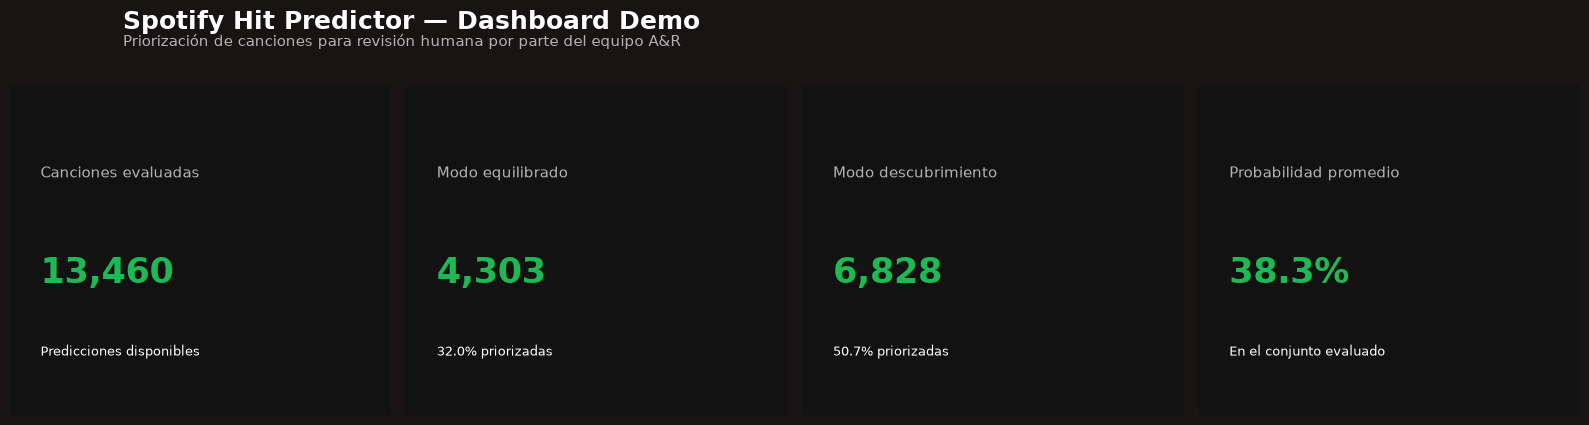

In [ ]:
# Dashboard principal — Indicadores de priorización

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

fig.patch.set_facecolor(spotify_black)

kpis = [
    (
        "Canciones evaluadas",
        f"{total_canciones:,}",
        "Predicciones disponibles"
    ),
    (
        "Modo equilibrado",
        f"{priorizadas_equilibrada:,}",
        f"{priorizadas_equilibrada / total_canciones:.1%} priorizadas"
    ),
    (
        "Modo descubrimiento",
        f"{priorizadas_descubrimiento:,}",
        f"{priorizadas_descubrimiento / total_canciones:.1%} priorizadas"
    ),
    (
        "Probabilidad promedio",
        f"{probabilidad_promedio:.1%}",
        "En el conjunto evaluado"
    )
]

for ax, (title, value, subtitle) in zip(axes, kpis):
    ax.set_facecolor(spotify_dark)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.text(
        0.08,
        0.72,
        title,
        fontsize=11,
        color=spotify_gray,
        transform=ax.transAxes
    )

    ax.text(
        0.08,
        0.40,
        value,
        fontsize=25,
        fontweight="bold",
        color=spotify_green,
        transform=ax.transAxes
    )

    ax.text(
        0.08,
        0.18,
        subtitle,
        fontsize=9.5,
        color=spotify_white,
        transform=ax.transAxes
    )

fig.suptitle(
    "Spotify Hit Predictor — Dashboard Demo",
    fontsize=18,
    fontweight="bold",
    color=spotify_white,
    x=0.08,
    ha="left",
    y=1.05
)

fig.text(
    0.08,
    0.96,
    "Priorización de canciones para revisión humana por parte del equipo A&R",
    fontsize=10.5,
    color=spotify_gray
)

plt.tight_layout()
plt.show()

In [ ]:
%pip install jinja2

   ---------------------------------------- 0.0/134.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/134.9 kB ? eta -:--:--
   --- ------------------------------------ 10.2/134.9 kB ? eta -:--:--
   ----------- --------------------------- 41.0/134.9 kB 393.8 kB/s eta 0:00:01
   -------------------------- ------------ 92.2/134.9 kB 655.4 kB/s eta 0:00:01
   -------------------------------------- 134.9/134.9 kB 729.0 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\anita\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# Top canciones priorizadas para revisión A&R

top_songs = (
    dashboard_data[
        [
            "track_name",
            "artists",
            "genres",
            "popularity",
            "probabilidad_popularidad",
            "decision_equilibrada",
            "decision_descubrimiento"
        ]
    ]
    .sort_values(
        "probabilidad_popularidad",
        ascending=False
    )
    .head(15)
    .copy()
)

top_songs["probabilidad_popularidad"] = (
    top_songs["probabilidad_popularidad"] * 100
).round(2)

top_songs = top_songs.rename(columns={
    "track_name": "Canción",
    "artists": "Artista",
    "genres": "Géneros",
    "popularity": "Popularidad real",
    "probabilidad_popularidad": "Probabilidad estimada (%)",
    "decision_equilibrada": "Decisión equilibrada",
    "decision_descubrimiento": "Decisión descubrimiento"
})

display(top_songs)

,Canción,Artista,Géneros,Popularidad real,Probabilidad estimada (%),Decisión equilibrada,Decisión descubrimiento
0,Twist,Neeraj Shridhar,hip-hop|pop-film,58.0,98.96,Priorizar revisión,Incluir en scouting
1,"Kar Har Maidaan Fateh (From ""Sanju"")",Sukhwinder Singh;Shreya Ghoshal;Vikram Montrose,hip-hop|pop-film,59.0,98.93,Priorizar revisión,Incluir en scouting
2,"Tujhe Kitna Chahne Lage (From ""Kabir Singh"")",Arijit Singh;Mithoon,pop|pop-film,72.0,98.86,Priorizar revisión,Incluir en scouting
3,Sweetheart,Dev Negi,pop|pop-film,66.0,98.80,Priorizar revisión,Incluir en scouting
4,"Shaamat (From ""Ek Villain Returns"")",Ankit Tiwari;Tara Sutaria,pop|pop-film,70.0,98.79,Priorizar revisión,Incluir en scouting
5,Ayyayo,G. V. Prakash;S. P. Balasubrahmanyam;S.P. Char...,pop|pop-film,66.0,98.79,Priorizar revisión,Incluir en scouting
6,Firecracker,Vishal-Shekhar;Vishal Dadlani;Shekhar Ravjiani...,pop|pop-film,67.0,98.79,Priorizar revisión,Incluir en scouting
7,Jogi,Yasser Desai;Aakanksha Sharma,pop|pop-film,67.0,98.78,Priorizar revisión,Incluir en scouting
8,Dooriyan,Mohit Chauhan,pop|pop-film,65.0,98.77,Priorizar revisión,Incluir en scouting
9,Ava Enna,Harris Jayaraj;Karthik;VV Prassanna,pop|pop-film,66.0,98.75,Priorizar revisión,Incluir en scouting


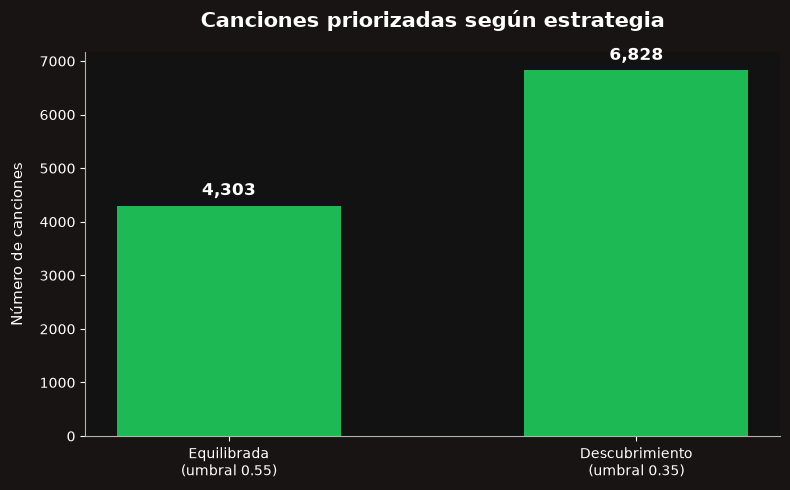

In [ ]:
# Comparación de estrategias de priorización

estrategias = pd.DataFrame({
    "Estrategia": ["Equilibrada\n(umbral 0.55)", "Descubrimiento\n(umbral 0.35)"],
    "Canciones priorizadas": [
        priorizadas_equilibrada,
        priorizadas_descubrimiento
    ]
})

fig, ax = plt.subplots(figsize=(8, 5))

fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

bars = ax.bar(
    estrategias["Estrategia"],
    estrategias["Canciones priorizadas"],
    color=spotify_green,
    width=0.55
)

ax.set_title(
    "Canciones priorizadas según estrategia",
    fontsize=15,
    fontweight="bold",
    color=spotify_white,
    pad=18
)

ax.set_ylabel(
    "Número de canciones",
    fontsize=11,
    color=spotify_white,
    labelpad=10
)

ax.tick_params(colors=spotify_white)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(spotify_gray)
ax.spines["bottom"].set_color(spotify_gray)

for bar, value in zip(bars, estrategias["Canciones priorizadas"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 120,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color=spotify_white
    )

plt.tight_layout()
plt.show()

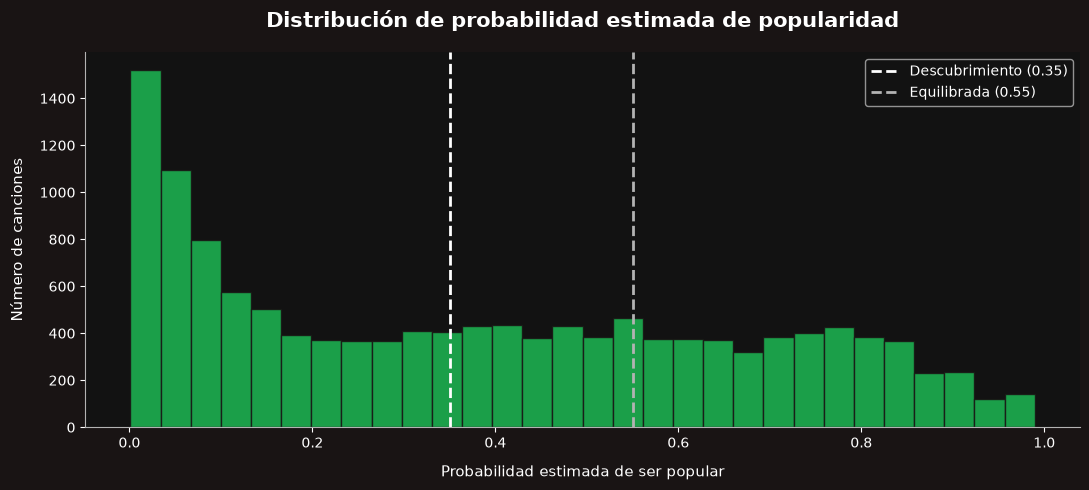

In [ ]:
# Distribución de probabilidades estimadas por el modelo

fig, ax = plt.subplots(figsize=(11, 5))

fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

ax.hist(
    dashboard_data["probabilidad_popularidad"],
    bins=30,
    color=spotify_green,
    edgecolor=spotify_black,
    alpha=0.85
)

ax.axvline(
    0.35,
    color=spotify_white,
    linestyle="--",
    linewidth=2,
    label="Descubrimiento (0.35)"
)

ax.axvline(
    0.55,
    color=spotify_gray,
    linestyle="--",
    linewidth=2,
    label="Equilibrada (0.55)"
)

ax.set_title(
    "Distribución de probabilidad estimada de popularidad",
    fontsize=15,
    fontweight="bold",
    color=spotify_white,
    pad=18
)

ax.set_xlabel(
    "Probabilidad estimada de ser popular",
    fontsize=11,
    color=spotify_white,
    labelpad=10
)

ax.set_ylabel(
    "Número de canciones",
    fontsize=11,
    color=spotify_white,
    labelpad=10
)

ax.tick_params(colors=spotify_white)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(spotify_gray)
ax.spines["bottom"].set_color(spotify_gray)

legend = ax.legend(
    facecolor=spotify_dark,
    edgecolor=spotify_gray,
    labelcolor=spotify_white
)

plt.tight_layout()
plt.show()

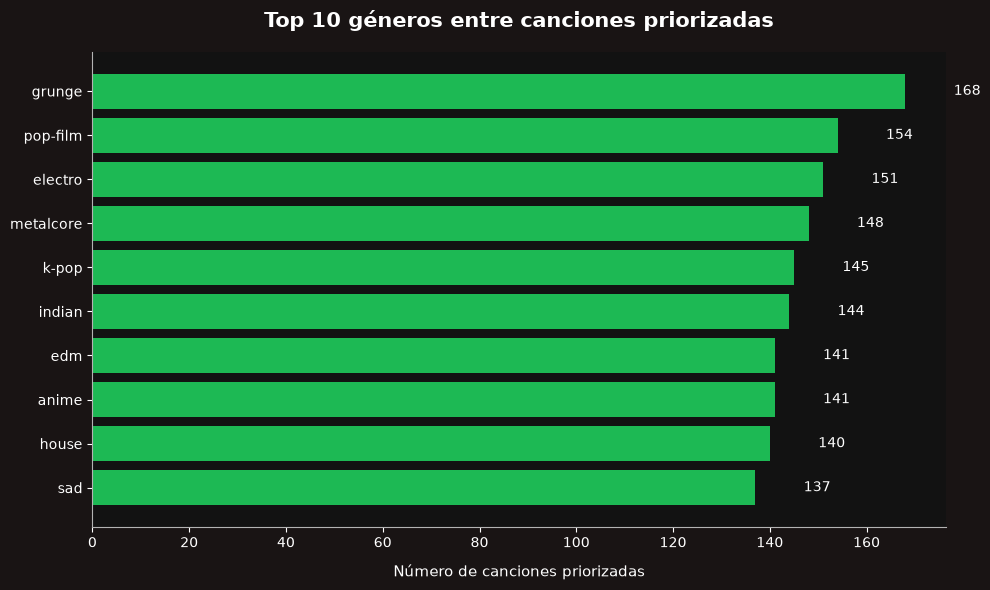

In [ ]:
# Géneros con más canciones priorizadas en estrategia equilibrada

genres_priorizados = (
    dashboard_data.loc[
        dashboard_data["prediccion_equilibrada"] == 1,
        ["genres"]
    ]
    .assign(
        genres=lambda df: df["genres"].fillna("").str.split("|")
    )
    .explode("genres")
)

top_genres = (
    genres_priorizados["genres"]
    .str.strip()
    .replace("", np.nan)
    .dropna()
    .value_counts()
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

bars = ax.barh(
    top_genres.index,
    top_genres.values,
    color=spotify_green
)

ax.set_title(
    "Top 10 géneros entre canciones priorizadas",
    fontsize=15,
    fontweight="bold",
    color=spotify_white,
    pad=18
)

ax.set_xlabel(
    "Número de canciones priorizadas",
    fontsize=11,
    color=spotify_white,
    labelpad=10
)

ax.tick_params(colors=spotify_white)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(spotify_gray)
ax.spines["bottom"].set_color(spotify_gray)

for bar, value in zip(bars, top_genres.values):
    ax.text(
        value + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center",
        fontsize=10,
        color=spotify_white
    )

plt.tight_layout()
plt.show()

In [ ]:
# Canciones que entran solo en modo descubrimiento

songs_discovery_only = (
    dashboard_data.loc[
        (dashboard_data["prediccion_equilibrada"] == 0) &
        (dashboard_data["prediccion_descubrimiento"] == 1),
        [
            "track_name",
            "artists",
            "genres",
            "popularity",
            "probabilidad_popularidad",
            "decision_equilibrada",
            "decision_descubrimiento"
        ]
    ]
    .sort_values(
        "probabilidad_popularidad",
        ascending=False
    )
    .head(15)
    .copy()
)

songs_discovery_only["probabilidad_popularidad"] = (
    songs_discovery_only["probabilidad_popularidad"] * 100
).round(2)

songs_discovery_only = songs_discovery_only.rename(columns={
    "track_name": "Canción",
    "artists": "Artista",
    "genres": "Géneros",
    "popularity": "Popularidad real",
    "probabilidad_popularidad": "Probabilidad estimada (%)",
    "decision_equilibrada": "Modo equilibrado",
    "decision_descubrimiento": "Modo descubrimiento"
})

print(
    "Canciones que solo se priorizan en estrategia de descubrimiento:",
    f"{len(dashboard_data.loc[(dashboard_data['prediccion_equilibrada'] == 0) & (dashboard_data['prediccion_descubrimiento'] == 1)]):,}"
)

display(songs_discovery_only)

Canciones que solo se priorizan en estrategia de descubrimiento: 2,525


,Canción,Artista,Géneros,Popularidad real,Probabilidad estimada (%),Modo equilibrado,Modo descubrimiento
4303,Aeibeli Hok,Papon,folk,35.0,54.99,No priorizar,Incluir en scouting
4304,My Wicked,GG Magree,dub|dubstep,42.0,54.99,No priorizar,Incluir en scouting
4305,車站,音樂磁場,mandopop,22.0,54.97,No priorizar,Incluir en scouting
4306,A Vida É Dela - Ao Vivo,Bom Gosto,pagode,52.0,54.97,No priorizar,Incluir en scouting
4307,War's das schon,Nockis,disco,30.0,54.97,No priorizar,Incluir en scouting
4308,In The Silence (Tritonia 399) - Eximinds Remix,Luminn;Roxanne Emery;Eximinds,trance,21.0,54.96,No priorizar,Incluir en scouting
4309,Run Away (The Escape Song),Oingo Boingo,synth-pop,24.0,54.95,No priorizar,Incluir en scouting
4310,Don't Go To Strangers,J.J. Cale,blues,61.0,54.94,No priorizar,Incluir en scouting
4311,Pankhon Ko,Salim–Sulaiman;Salim Merchant;Jaideep Sahni,folk,41.0,54.94,No priorizar,Incluir en scouting
4312,Abra os Olhos do Meu Coração - Ao Vivo em Curi...,David Quinlan,brazil|gospel,46.0,54.92,No priorizar,Incluir en scouting


In [ ]:
# Función de consulta para el equipo A&R

def consultar_canciones(
    genero=None,
    estrategia="equilibrada",
    limite=15
):
    """
    Filtra canciones priorizadas según género y estrategia.

    Parámetros
    ----------
    genero : str, opcional
        Palabra o género a buscar, por ejemplo: "pop", "reggaeton" o "rock".
    estrategia : str
        "equilibrada" para umbral 0.55 o "descubrimiento" para umbral 0.35.
    limite : int
        Número máximo de canciones a mostrar.
    """

    estrategia = estrategia.lower().strip()

    if estrategia not in ["equilibrada", "descubrimiento"]:
        raise ValueError(
            "La estrategia debe ser 'equilibrada' o 'descubrimiento'."
        )

    columna_prediccion = (
        "prediccion_equilibrada"
        if estrategia == "equilibrada"
        else "prediccion_descubrimiento"
    )

    resultado = dashboard_data.loc[
        dashboard_data[columna_prediccion] == 1
    ].copy()

    if genero is not None:
        resultado = resultado[
            resultado["genres"]
            .fillna("")
            .str.contains(genero, case=False, na=False)
        ]

    resultado = (
        resultado.sort_values(
            "probabilidad_popularidad",
            ascending=False
        )
        .head(limite)
        .copy()
    )

    columnas_mostrar = [
        "track_name",
        "artists",
        "genres",
        "probabilidad_popularidad",
        "decision_equilibrada",
        "decision_descubrimiento"
    ]

    resultado = resultado[columnas_mostrar].rename(columns={
        "track_name": "Canción",
        "artists": "Artista",
        "genres": "Géneros",
        "probabilidad_popularidad": "Probabilidad estimada",
        "decision_equilibrada": "Modo equilibrado",
        "decision_descubrimiento": "Modo descubrimiento"
    })

    resultado["Probabilidad estimada"] = (
        resultado["Probabilidad estimada"] * 100
    ).round(2).astype(str) + "%"

    titulo_genero = (
        f' del género "{genero}"'
        if genero is not None
        else ""
    )

    print(
        f"Resultados priorizados{titulo_genero} "
        f"— estrategia {estrategia}"
    )
    print(f"Coincidencias mostradas: {len(resultado)}")

    display(resultado)

In [ ]:
# Ejemplos de consulta para la demo

consultar_canciones(
    genero="pop",
    estrategia="equilibrada",
    limite=10
)

Resultados priorizados del género "pop" — estrategia equilibrada
Coincidencias mostradas: 10


,Canción,Artista,Géneros,Probabilidad estimada,Modo equilibrado,Modo descubrimiento
0,Twist,Neeraj Shridhar,hip-hop|pop-film,98.96%,Priorizar revisión,Incluir en scouting
1,"Kar Har Maidaan Fateh (From ""Sanju"")",Sukhwinder Singh;Shreya Ghoshal;Vikram Montrose,hip-hop|pop-film,98.93%,Priorizar revisión,Incluir en scouting
2,"Tujhe Kitna Chahne Lage (From ""Kabir Singh"")",Arijit Singh;Mithoon,pop|pop-film,98.86%,Priorizar revisión,Incluir en scouting
3,Sweetheart,Dev Negi,pop|pop-film,98.8%,Priorizar revisión,Incluir en scouting
4,"Shaamat (From ""Ek Villain Returns"")",Ankit Tiwari;Tara Sutaria,pop|pop-film,98.79%,Priorizar revisión,Incluir en scouting
5,Ayyayo,G. V. Prakash;S. P. Balasubrahmanyam;S.P. Char...,pop|pop-film,98.79%,Priorizar revisión,Incluir en scouting
6,Firecracker,Vishal-Shekhar;Vishal Dadlani;Shekhar Ravjiani...,pop|pop-film,98.79%,Priorizar revisión,Incluir en scouting
7,Jogi,Yasser Desai;Aakanksha Sharma,pop|pop-film,98.78%,Priorizar revisión,Incluir en scouting
8,Dooriyan,Mohit Chauhan,pop|pop-film,98.77%,Priorizar revisión,Incluir en scouting
9,Ava Enna,Harris Jayaraj;Karthik;VV Prassanna,pop|pop-film,98.75%,Priorizar revisión,Incluir en scouting




## Uso responsable del Dashboard

Este dashboard funciona como una herramienta de apoyo para el equipo de A&R y no reemplaza el criterio humano.

- Las recomendaciones se basan en atributos de audio, duración, ritmo y géneros musicales.
- La estrategia **equilibrada** prioriza menos canciones y permite una revisión más selectiva.
- La estrategia de **descubrimiento** amplía el scouting para disminuir el riesgo de dejar pasar canciones con potencial.
- Los resultados mostrados provienen del conjunto de prueba utilizado para la demostración técnica.
- Antes de tomar una decisión de inversión, el equipo debe complementar la predicción con revisión artística, contexto de mercado, identidad del artista y criterios humanos.
- Se debe monitorear periódicamente el desempeño por grupos musicales para evitar brechas de cobertura entre géneros mainstream y géneros latino/emergentes.

> **Decisión final:** el modelo prioriza oportunidades; las personas toman la decisión de negocio.

In [ ]:
# Resumen ejecutivo para la demo

resumen_dashboard = pd.DataFrame({
    "Indicador": [
        "Canciones evaluadas",
        "Priorizadas — estrategia equilibrada",
        "Priorizadas — estrategia descubrimiento",
        "Canciones adicionales en descubrimiento",
        "Probabilidad promedio estimada"
    ],
    "Valor": [
        f"{total_canciones:,}",
        f"{priorizadas_equilibrada:,}",
        f"{priorizadas_descubrimiento:,}",
        f"{priorizadas_descubrimiento - priorizadas_equilibrada:,}",
        f"{probabilidad_promedio:.2%}"
    ]
})

display(resumen_dashboard)

print("CONCLUSIÓN DE LA DEMO")
print("-" * 55)
print(
    "La estrategia equilibrada concentra la revisión en las canciones "
    "con mayor probabilidad estimada."
)
print(
    "La estrategia de descubrimiento amplía el scouting e incorpora "
    f"{priorizadas_descubrimiento - priorizadas_equilibrada:,} canciones adicionales."
)
print(
    "El resultado debe interpretarse como una recomendación para revisión "
    "humana, no como una decisión automática de inversión."
)

,Indicador,Valor
0,Canciones evaluadas,"13,460"
1,Priorizadas — estrategia equilibrada,"4,303"
2,Priorizadas — estrategia descubrimiento,"6,828"
3,Canciones adicionales en descubrimiento,"2,525"
4,Probabilidad promedio estimada,38.34%


CONCLUSIÓN DE LA DEMO
-------------------------------------------------------
La estrategia equilibrada concentra la revisión en las canciones con mayor probabilidad estimada.
La estrategia de descubrimiento amplía el scouting e incorpora 2,525 canciones adicionales.
El resultado debe interpretarse como una recomendación para revisión humana, no como una decisión automática de inversión.
